In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
def csv2db(path2csv: Path, conn) -> None:
    df = pd.read_csv(path2csv, parse_dates=['datetime'], dtype={'status_Code': 'Int64', 'lat': 'Float64', 'lon': 'Float64'})
    df.to_sql("logs", conn, if_exists="replace", index=False)

In [2]:
current_dir = Path.cwd()
data_dir = Path(current_dir, 'data.philiplessner.com')
path2processed = data_dir /'log_processed.csv'
print(str(path2processed))

/media/phil/m2ssd/web/logs/data.philiplessner.com/log_processed.csv


In [3]:
conn = sqlite3.connect(Path(data_dir, 'logs.db'))

In [5]:
csv2db(path2processed, conn)

In [6]:
conn.close()

In [7]:

conn = sqlite3.connect(Path(data_dir, 'logs.db'))

In [8]:
query = "SELECT * FROM logs WHERE Agent_Type == 'H'"
df_human = pd.read_sql_query(query, conn)

In [9]:
df_human.head()

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
0,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.8200,Asia/Singapore
1,154.159.252.207,2026-07-12 12:02:19+00:00,GET,/photos/australia,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10) ...,H,Kenya,KE,30,Nairobi County,Nairobi,9831,-1.28410,36.8155,Africa/Nairobi
2,171.250.162.196,2026-07-12 12:35:37+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_3_1)...,H,Vietnam,VN,SG,Ho Chi Minh,Ho Chi Minh City,700000,10.82200,106.6257,Asia/Ho_Chi_Minh
3,190.62.87.242,2026-07-12 13:21:14+00:00,GET,/blog/0,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,H,El Salvador,SV,SS,San Salvador Department,San Salvador,NaN,13.69270,-89.1917,America/El_Salvador
4,138.84.33.34,2026-07-12 14:59:35+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,H,Chile,CL,RM,Santiago Metropolitan,Santiago,NaN,-33.44880,-70.6692,America/Santiago


In [8]:
df_human['ip_address'].count()

np.int64(1813)

In [10]:
start_date = "2026-07-20 00:00:00"
end_date = "2026-08-14 23:59:59"
query = """
SELECT countryCode, COUNT(*) AS count
FROM logs
WHERE Agent_Type == 'H'
AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
GROUP BY countryCode
ORDER BY count DESC;
"""
by_country = pd.read_sql_query(query, conn, params=(start_date, end_date))
print(by_country)

   countryCode  count
0           CN    294
1           US    249
2           SG     58
3           DE     40
4           CA     36
..         ...    ...
74          BY      1
75          BO      1
76          BH      1
77          AT      1
78          AE      1

[79 rows x 2 columns]


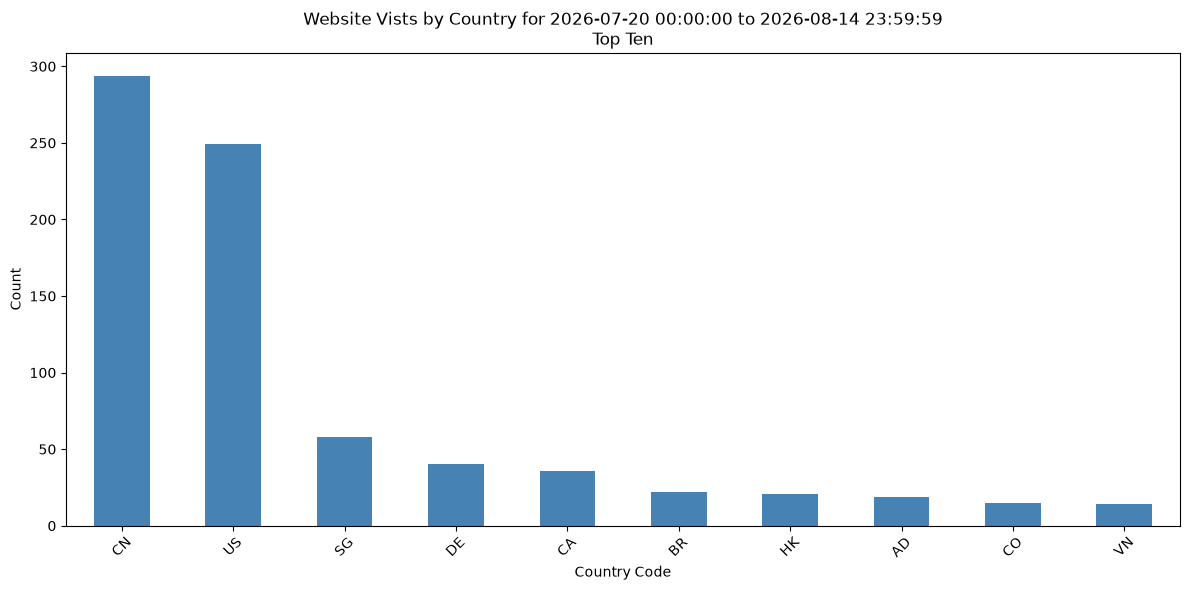

In [11]:
by_country[:10].plot(x='countryCode', y='count', kind='bar', figsize=(12, 6), color='steelblue', legend=None)
plt.title(f'Website Vists by Country for {start_date} to {end_date}\nTop Ten')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [12]:
conn.close()